# Import thư viện và dữ liệu

In [1]:
import requests
import time
import re
import unicodedata
from tqdm.auto import tqdm

import pandas as pd
import os
import configparser
from neo4j import GraphDatabase
import textwrap
import matplotlib.pyplot as plt
import numpy as np
# Thiết lập định dạng hiển thị cho các giá trị float, tránh dùng ký hiệu khoa học cho số lớn
pd.options.display.float_format = '{:.0f}'.format


d:\Thac_Si\De_an_thac_si\code\KG-Rec-Sys-Tourism-SG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Tải file poi_info.csv vào DataFrame df_poi_info
poi_info_file = "./raw_data/poi_info_filter.csv"
df_poi_info = pd.read_csv(poi_info_file)

# Loại bỏ các POI trùng lặp dựa trên cột 'id'
df_poi_info.drop_duplicates(subset=['id'], inplace=True)

# Hiển thị vài dòng đầu của df_poi_info để kiểm tra xem đã tải đúng chưa
df_poi_info.head(2)

,id,url,name,type,openingHours,description,duration,price,address_original,address,region,avgRating,numReviews,numReviews_5,numReviews_4,numReviews_3,numReviews_2,numReviews_1,latitude,longitude
0,311103,https://www.tripadvisor.com.vn/Attraction_Revi...,War Remnants Museum,Viện bảo tàng lịch sử,Mo-Su 07:30-17:30,Bảo tàng Chứng tích Chiến tranh là đơn vị trực...,1-2 giờ,NaN,"28 Vo Van Tan Phường Võ Thị Sáu, Quận 3, Thành...","28 Võ Văn Tần, Thành phố Hồ Chí Minh",Thành phố Hồ Chí Minh,4,33656,17384,11986,3435,566,285,11,107
1,2005826,https://www.tripadvisor.com.vn/Attraction_Revi...,Cu Chi Tunnels,Điểm thu hút khách tham quan & thắng cảnh,Mo-Su 07:00-17:00,Trong chuyến tham quan có hướng dẫn đến Địa đạ...,2-3 giờ,NaN,"Phú Hiệp , Thành phố Hồ Chí Minh","Tỉnh lộ 15, Ấp Phú Hiệp, Thành phố Hồ Chí Minh",Thành phố Hồ Chí Minh,4,26270,14611,8604,2309,479,267,11,106


In [3]:
# Tải file reviews.csv vào DataFrame df_reviews
reviews_file = "./raw_data/reviews_filter.csv"
df_reviews = pd.read_csv(reviews_file)

# Hiển thị vài dòng đầu của df_reviews để xác nhận đã tải thành công
df_reviews.head()

,poiID,username,location,review_id,review_url,title,content,rating,date,user_group
0,311103,OnAir50792827286,NaN,1066071840,https://www.tripadvisor.com.vn/ShowUserReviews...,Lần đầu thăm quan bảo tàng Chứng tích chiến tranh,Trải nghiệm của mình khi đến thăm quan bảo tàn...,5,"28 tháng 6, 2026",Bạn bè
1,311103,Paradise07663862175,NaN,1066071372,https://www.tripadvisor.com.vn/ShowUserReviews...,goodjob,"trải nghiệm tốt, nhân viên hướng dẫn nhiệt tìn...",5,"28 tháng 6, 2026",Bạn bè
2,311103,l_ng_c_2026,NaN,1066071361,https://www.tripadvisor.com.vn/ShowUserReviews...,Chứng tích chiến tranh chiến đi bảo tàng,Đi bảo tàng rất đẹp và ý nghĩa không khí mát mẻ,5,"28 tháng 6, 2026",Bạn bè
3,311103,Trip49632276562,NaN,1066071274,https://www.tripadvisor.com.vn/ShowUserReviews...,Tốt,"Trải nghiệm tốt,tốt,, dịch vụ tốt, không khí s...",5,"28 tháng 6, 2026",Bạn bè
4,311103,Go24271942310,NaN,1066071208,https://www.tripadvisor.com.vn/ShowUserReviews...,Chuyến du ngoạn bảo tàng,"Ok con tê tê, bảo tàng rất đẹp và ý nghĩa",4,"28 tháng 6, 2026",Bạn bè


In [ ]:
# Lọc POI
# - thiếu tọa độ
# - tên mơ hồ hoặc trống
# - địa chỉ quá chung chung / trống
# - mô tả không hữu ích / trống
# - không có review
# Khoảng 30 phút

# CẤU HÌNH
GEOAPIFY_API_KEY = "7b2ca1c8f4bf407b938e7286372b7e93"
REVERSE_GEOCODE_URL = "https://api.geoapify.com/v1/geocode/reverse"
SLEEP_SECONDS = 0.05

# GIỮ LẠI address crawl ban đầu
if "address_original" not in df_poi_info.columns:
    df_poi_info.rename(columns={"address": "address_original"}, inplace=True)

# Chỉ tạo/cập nhật cột address, không reorder cột
df_poi_info["address"] = pd.NA

# HÀM PHỤ TRỢ
def clean_text(value):
    if value is None or pd.isna(value):
        return ""
    value = unicodedata.normalize("NFC", str(value))
    value = re.sub(r"\s+", " ", value)
    return value.strip(" ,.-")


def pick_value(props, keys):
    for key in keys:
        val = props.get(key)
        if val:
            return clean_text(val)
    return ""


def normalize_ward(ward):
    ward = clean_text(ward)
    if not ward:
        return ""

    if re.match(r"^(Quận|Huyện|District|Thành phố Thủ Đức|Thành phố)\b", ward, flags=re.IGNORECASE):
        return ""

    return ward


def format_new_address(props):
    """
    Chuẩn đầu ra:
    Số nhà + tên đường, phường, Thành phố Hồ Chí Minh

    Không bịa số nhà/đường nếu API không có.
    """
    house_number = pick_value(props, ["housenumber"])
    street = pick_value(props, ["street"])
    ward = normalize_ward(
        pick_value(props, ["suburb", "district", "city_district", "neighbourhood", "quarter"])
    )

    city = "Thành phố Hồ Chí Minh"
    street_address = " ".join([x for x in [house_number, street] if x]).strip()

    if not street_address:
        street_address = clean_text(props.get("formatted", ""))
        street_address = re.sub(r",?\s*Việt Nam$", "", street_address, flags=re.IGNORECASE)
        street_address = re.sub(r",?\s*\d{5,6}(?=,|$)", "", street_address)
        street_address = re.sub(
            r",?\s*(Quận|Huyện|District)\s*[^,]*",
            "",
            street_address,
            flags=re.IGNORECASE
        )
        street_address = re.sub(
            r",?\s*Thành phố Hồ Chí Minh",
            "",
            street_address,
            flags=re.IGNORECASE
        )
        street_address = street_address.strip(" ,.-")

    parts = [x for x in [street_address, ward, city] if x]

    unique_parts = []
    seen = set()
    for part in parts:
        key = part.lower()
        if key not in seen:
            unique_parts.append(part)
            seen.add(key)

    return ", ".join(unique_parts) if unique_parts else pd.NA


def reverse_geocode(lat, lon, session):
    if pd.isna(lat) or pd.isna(lon):
        return pd.NA

    try:
        lat = float(lat)
        lon = float(lon)
    except (TypeError, ValueError):
        return pd.NA

    params = {
        "lat": lat,
        "lon": lon,
        "apiKey": GEOAPIFY_API_KEY,
        "lang": "vi"
    }
    headers = {"Accept": "application/json"}

    try:
        response = session.get(
            REVERSE_GEOCODE_URL,
            params=params,
            headers=headers,
            timeout=20
        )
        response.raise_for_status()
        data = response.json()

        features = data.get("features", [])
        if not features:
            return pd.NA

        props = features[0].get("properties", {})
        return format_new_address(props)

    except requests.RequestException:
        return pd.NA


# HÀM ĐÁNH GIÁ DÒNG RÁC / MƠ HỒ KHI THIẾU TỌA ĐỘ
# Chỉ xóa nếu:
# - thiếu tọa độ
# - tên mơ hồ hoặc trống
# - địa chỉ quá chung chung / trống
# - mô tả không hữu ích / trống
# - không có review
GENERIC_NAME_PATTERNS = [
    r"^thành phố hồ chí minh$",
    r"^sài gòn$",
    r"^saigon$",
    r"^ho chi minh$",
    r"^ho chi minh city$",
    r"^district\s*\d+$",
    r"^quận\s*\d+$",
    r"^phường\s*\d+$",
    r"^ward\s*\d+$",
    r"^unknown$",
    r"^n/?a$",
    r"^test$"
]

GENERIC_ADDRESS_PATTERNS = [
    r"^thành phố hồ chí minh$",
    r"^tp\.?\s*hồ chí minh$",
    r"^hồ chí minh$",
    r"^ho chi minh city$",
    r"^sài gòn$",
    r"^saigon$",
    r"^việt nam$",
    r"^thành phố hồ chí minh,\s*việt nam$"
]

USELESS_DESCRIPTION_PATTERNS = [
    r"^$",
    r"^nan$",
    r"^none$",
    r"^n/?a$",
    r"^đang cập nhật$",
    r"^update later$",
    r"^coming soon$",
    r"^xem thêm$"
]


def text_matches_any_pattern(text, patterns):
    text = clean_text(text).lower()
    if not text:
        return True
    return any(re.match(pattern, text, flags=re.IGNORECASE) for pattern in patterns)


def is_name_ambiguous(name):
    name = clean_text(name)
    if not name:
        return True
    if len(name) < 3:
        return True
    return text_matches_any_pattern(name, GENERIC_NAME_PATTERNS)


def is_address_too_generic(address_original):
    addr = clean_text(address_original)
    if not addr:
        return True
    return text_matches_any_pattern(addr, GENERIC_ADDRESS_PATTERNS)


def is_description_unhelpful(description):
    desc = clean_text(description)
    if not desc:
        return True
    if text_matches_any_pattern(desc, USELESS_DESCRIPTION_PATTERNS):
        return True
    if len(desc) < 20:
        return True
    return False


def has_no_reviews(row):
    num_reviews = row.get("numReviews")

    try:
        if pd.isna(num_reviews):
            return True
        return float(num_reviews) <= 0
    except (TypeError, ValueError):
        return True


def should_drop_row(row):
    lat, lon = row.get("latitude"), row.get("longitude")
    if not (pd.isna(lat) or pd.isna(lon)):
        return False

    ambiguous_name = is_name_ambiguous(row.get("name"))
    generic_address = is_address_too_generic(row.get("address_original"))
    unhelpful_description = is_description_unhelpful(row.get("description"))
    no_reviews = has_no_reviews(row)

    if ambiguous_name:
        return True
    if no_reviews and unhelpful_description:
        return True
    if no_reviews and generic_address:
        return True
    if generic_address and unhelpful_description:
        return True
    return False


# CHẠY TOÀN BỘ
# 1) Có tọa độ -> reverse geocode
# 2) Không có tọa độ -> dùng address_original luôn
coordinate_cache = {}
session = requests.Session() 
for index, row in tqdm(
    df_poi_info.iterrows(),
    total=len(df_poi_info),
    desc="Geoapify reverse geocoding"
):
    lat = row.get("latitude")
    lon = row.get("longitude")
    addr_original = row.get("address_original")

    new_address = pd.NA

    has_coord = False
    try:
        if not pd.isna(lat) and not pd.isna(lon):
            coord_key = (round(float(lat), 6), round(float(lon), 6))
            has_coord = True
        else:
            coord_key = None
    except (TypeError, ValueError):
        has_coord = False
        coord_key = None

    if has_coord:
        if coord_key not in coordinate_cache:
            coordinate_cache[coord_key] = reverse_geocode(
                lat=coord_key[0],
                lon=coord_key[1],
                session=session
            )
            time.sleep(SLEEP_SECONDS)

        new_address = coordinate_cache[coord_key]

    # Không có tọa độ hoặc reverse không ra kết quả -> giữ nguyên address_original
    if pd.isna(new_address):
        new_address = addr_original if not pd.isna(addr_original) else pd.NA

    df_poi_info.at[index, "address"] = new_address

# LỌC BỎ DÒNG THIẾU TỌA ĐỘ + MƠ HỒ / RÁC DỮ LIỆU
drop_mask = df_poi_info.apply(should_drop_row, axis=1)

n_before = len(df_poi_info)
n_drop = int(drop_mask.sum())

df_removed = df_poi_info[drop_mask].copy()
df_poi_info = df_poi_info[~drop_mask].copy()

# Lọc bỏ các review có poiID thuộc về các POI đã bị xóa
n_reviews_before = len(df_reviews)
df_reviews = df_reviews[df_reviews["poiID"].isin(df_poi_info["id"])].copy()
n_reviews_after = len(df_reviews)

n_after = len(df_poi_info)

cols = list(df_poi_info.columns)

for col in ["address_original", "address"]:
    if col in cols:
        cols.remove(col)

if "price" in cols:
    price_idx = cols.index("price")
    cols = cols[:price_idx + 1] + ["address_original", "address"] + cols[price_idx + 1:]

df_poi_info = df_poi_info[cols]

removed_cols = [c for c in cols if c in df_removed.columns]
df_removed = df_removed[removed_cols]
# LƯU FILE
output_file = "./raw_data/poi_info_filter.csv"
removed_file = "./raw_data/poi_info_removed.csv"
output_file_review = "./raw_data/reviews_filter.csv"
df_poi_info.to_csv(output_file, index=False, encoding="utf-8-sig")
df_removed.to_csv(removed_file, index=False, encoding="utf-8-sig")
df_reviews.to_csv(output_file_review, index=False, encoding="utf-8-sig")

print(f"Đã lưu file chính: {output_file}")
print(f"Đã lưu file bị loại: {removed_file}")
print("Tổng số dòng ban đầu:", n_before)
print("Số dòng bị loại:", n_drop)
print("Số dòng còn lại:", n_after)
print(f"Số lượng reviews ban đầu: {n_reviews_before}")
print(f"Số lượng reviews còn lại: {n_reviews_after}")

Geoapify reverse geocoding: 100%|██████████| 3326/3326 [24:51<00:00,  2.23it/s]


Đã lưu file chính: ./raw_data/poi_info_filter.csv
Đã lưu file bị loại: ./raw_data/poi_info_removed.csv
Tổng số dòng ban đầu: 3326
Số dòng bị loại: 0
Số dòng còn lại: 3326
Số lượng reviews ban đầu: 24251
Số lượng reviews còn lại: 24108


In [4]:
# Ontology ánh xạ địa chỉ cũ và mới trước/sau sáp nhập ở TP.HCM
import json
import re
import unicodedata

def norm_str(s):
    if not s:
        return ""
    return unicodedata.normalize('NFC', s).lower().strip()

def clean_street_part(street, found_ward, new_ward_name, detected_district, d_name_std):
    patterns_to_remove = []
    
    ward_names = [new_ward_name]
    if found_ward:
        ward_names.append(found_ward)
    
    for w in ward_names:
        w_norm = norm_str(w)
        w_clean = re.sub(r'^(phường|xã|thị trấn)\s+', '', w_norm).strip()
        patterns_to_remove.extend([
            rf'\bphường\s+{w_clean}\b',
            rf'\bp\.\s*{w_clean}\b',
            rf'\bp\s+{w_clean}\b',
            rf'\b{w_clean}\b'
        ])
        
    district_names = []
    if detected_district:
        district_names.append(detected_district)
    if d_name_std:
        district_names.append(d_name_std)
        
    # Nếu quận liên quan đến Thủ Đức, bao gồm tất cả các tên lịch sử
    if any(name in ["Thành phố Thủ Đức", "Thủ Đức", "Quận 2", "Quận 9", "Quận Thủ Đức"] for name in district_names):
        district_names.extend(["Thành phố Thủ Đức", "Thủ Đức", "Quận 2", "Quận 9", "Quận Thủ Đức"])
        
    for d in set(district_names):
        d_norm = norm_str(d)
        d_clean = re.sub(r'^(quận|huyện|thành phố)\s+', '', d_norm).strip()
        patterns_to_remove.extend([
            rf'\bquận\s+{d_clean}\b',
            rf'\bq\.\s*{d_clean}\b',
            rf'\bq\s+{d_clean}\b',
            rf'\bthành phố\s+{d_clean}\b',
            rf'\btp\.\s*{d_clean}\b',
            rf'\btp\s+{d_clean}\b'
        ])
        if not d_clean.isdigit():
            patterns_to_remove.append(rf'\b{d_clean}\b')
        else:
            patterns_to_remove.extend([
                rf'\bq{d_clean}\b',
                rf'\bq\.{d_clean}\b',
                rf'\bd{d_clean}\b',
                rf'\bd\.{d_clean}\b',
                rf'\bdistrict\s+{d_clean}\b',
                rf'\bdist\.\s*{d_clean}\b',
                rf'\bdist\s+{d_clean}\b'
            ])
            
    patterns_to_remove.extend([
        r'\bthành phố hồ chí minh\b',
        r'\bhồ chí minh\b',
        r'\btp\.hcm\b',
        r'\btphcm\b',
        r'\btp\s+hcm\b',
        r'\bhcm\b',
        r'\bho chi minh\b'
    ])
    
    # Sort by length descending
    patterns_to_remove = sorted(list(set(patterns_to_remove)), key=len, reverse=True)
    
    street_clean = street
    for pat in patterns_to_remove:
        street_clean = re.sub(pat, '', street_clean, flags=re.IGNORECASE)
        
    # Clean up excess commas and spaces
    street_clean = re.sub(r'\s*,\s*', ', ', street_clean)
    street_clean = re.sub(r',\s*,', ',', street_clean)
    street_clean = re.sub(r'^[,.\s]+', '', street_clean)
    street_clean = re.sub(r'[,.\s]+$', '', street_clean)
    street_clean = re.sub(r'\s+', ' ', street_clean).strip()
    
    return street_clean

def extract_street(addr, found_ward, new_ward_name, detected_district, d_name_std):
    addr_clean = re.sub(r'\s+', ' ', addr).strip()
    parts = [p.strip() for p in addr_clean.split(',')]
    
    street_parts = []
    
    ward_terms = {norm_str(found_ward), norm_str(new_ward_name)} if found_ward else {norm_str(new_ward_name)}
    ward_terms.add(re.sub(r'^(phường|xã|thị trấn)\s+', '', norm_str(new_ward_name)).strip())
    if found_ward:
        ward_terms.add(re.sub(r'^(phường|xã|thị trấn)\s+', '', norm_str(found_ward)).strip())
        
    district_terms = set()
    if detected_district:
        district_terms.add(norm_str(detected_district))
    if d_name_std:
        district_terms.add(norm_str(d_name_std))
        
    # Nếu quận liên quan đến Thủ Đức, thêm tất cả các thuật ngữ lịch sử vào district_terms
    if any(name in ["thành phố thủ đức", "thủ đức", "quận 2", "quận 9", "quận thủ đức"] for name in district_terms):
        district_terms.update(["thành phố thủ đức", "thủ đức", "quận 2", "quận 9", "quận thủ đức", "q.2", "q.9", "q2", "q9"])
        
    for d in list(district_terms):
        d_n = norm_str(d)
        district_terms.add(d_n)
        district_terms.add(re.sub(r'^(quận|huyện|thành phố)\s+', '', d_n).strip())
        
    city_terms = {
        "thành phố hồ chí minh", "hồ chí minh", "tp.hcm", "tphcm", "tp hcm", "hcm", "ho chi minh", "ho chi minh city", "hcmc",
        "thành phố thủ đức", "thủ đức", "thu duc", "thu duc district", "district 2", "district 9", "quận 2", "quận 9", "quận thủ đức"
    }
    
    for p in parts:
        p_norm = norm_str(p)
        is_ward = any(term == p_norm or f"phường {term}" == p_norm or f"xã {term}" == p_norm for term in ward_terms)
        is_district = any(term == p_norm or f"quận {term}" == p_norm or f"huyện {term}" == p_norm or f"thành phố {term}" == p_norm for term in district_terms)
        is_city = p_norm in city_terms or re.sub(r'^(thành phố|tỉnh)\s+', '', p_norm).strip() in city_terms
        is_zip = p_norm.isdigit() and len(p_norm) >= 5
        
        if not (is_ward or is_district or is_city or is_zip or not p_norm):
            p_clean = re.sub(r'^(phường|quận|huyện|thành phố|p\.|q\.|h\.|tp\.)\s*', '', p_norm).strip()
            if p_clean in ward_terms or p_clean in district_terms or p_clean in city_terms:
                continue
            street_parts.append(p)
            
    street_part = ", ".join(street_parts)
    if not street_part:
        match_street = re.split(r'(phường|quận|huyện|district|dist|p\.|q\.)', addr_clean, maxsplit=1, flags=re.IGNORECASE)
        street_part = match_street[0].strip()
        street_part = re.sub(r'[,.\s]+$', '', street_part).strip()
        
    return clean_street_part(street_part, found_ward, new_ward_name, detected_district, d_name_std)

districts_list = [
    "Quận 1", "Quận 3", "Quận 4", "Quận 5", "Quận 6", "Quận 7", "Quận 8", "Quận 10", "Quận 11", "Quận 12",
    "Quận Bình Thạnh", "Quận Bình Tân", "Quận Gò Vấp", "Quận Phú Nhuận", "Quận Tân Bình", "Quận Tân Phú",
    "Huyện Bình Chánh", "Huyện Cần Giờ", "Huyện Củ Chi", "Huyện Hóc Môn", "Huyện Nhà Bè",
    "Thành phố Thủ Đức", "Thủ Đức", "Quận 2", "Quận 9"
]

district_patterns = []
for d in districts_list:
    d_norm = norm_str(d)
    district_patterns.append((d_norm, d))
    match = re.match(r'^(quận|huyện)\s+(.+)$', d_norm)
    if match:
        prefix, rest = match.groups()
        if prefix == "quận":
            district_patterns.append((f"district {rest}", d))
            district_patterns.append((f"dist. {rest}", d))
            district_patterns.append((f"dist {rest}", d))
            district_patterns.append((f"d.{rest}", d))
            district_patterns.append((f"d {rest}", d))
            district_patterns.append((f"q. {rest}", d))
            district_patterns.append((f"q {rest}", d))
            if rest.isdigit():
                district_patterns.append((f"q{rest}", d))
                district_patterns.append((f"d{rest}", d))
                district_patterns.append((f"q.{rest}", d))
                district_patterns.append((f"d.{rest}", d))
        elif prefix == "huyện":
            district_patterns.append((f"h. {rest}", d))
            district_patterns.append((f"h {rest}", d))

district_patterns = sorted(district_patterns, key=lambda x: len(x[0]), reverse=True)

with open("./raw_data/hcm_address_mapping.json", "r", encoding="utf-8") as f:
    mapping_data = json.load(f)

# Inject missing old ward mappings for Thủ Đức
mapping_data["ward_mappings"].extend([
    {
        "id": "manual_binh_an",
        "old_ward_code": "27103",
        "old_ward_name": "Phường Bình An",
        "old_district_name": "Thành phố Thủ Đức",
        "old_province_name": "Thành phố Hồ Chí Minh",
        "new_ward_code": "27094",
        "new_ward_name": "Phường An Khánh",
        "new_province_name": "Thành phố Hồ Chí Minh"
    },
    {
        "id": "manual_binh_khanh",
        "old_ward_code": "27101",
        "old_ward_name": "Phường Bình Khánh",
        "old_district_name": "Thành phố Thủ Đức",
        "old_province_name": "Thành phố Hồ Chí Minh",
        "new_ward_code": "27094",
        "new_ward_name": "Phường An Khánh",
        "new_province_name": "Thành phố Hồ Chí Minh"
    }
])

ward_mapping_lookup = {}
districts_set = set()
wards_dict = {}
ward_to_district_rel = set()
ward_mergers = set()
all_old_wards_by_district = {}
ward_name_to_districts = {}

for item in mapping_data["ward_mappings"]:
    old_code = item.get("old_ward_code")
    old_name = item.get("old_ward_name")
    old_district = item.get("old_district_name")
    new_code = item.get("new_ward_code")
    new_name = item.get("new_ward_name")
    
    if old_district in ["Quận 2", "Quận 9", "Quận Thủ Đức", "Thủ Đức", "Thành phố Thủ Đức"]:
        new_district = "Thành phố Thủ Đức"
    else:
        new_district = old_district
        
    if old_district:
        districts_set.add(old_district)
    if new_district:
        districts_set.add(new_district)
        
    if old_code and old_name:
        if old_code not in wards_dict:
            wards_dict[old_code] = {
                "ward_code": old_code,
                "name": old_name,
                "province_code": "79"
            }
        if old_district:
            ward_to_district_rel.add((old_code, new_district))
            
    if new_code and new_name:
        if new_code not in wards_dict:
            wards_dict[new_code] = {
                "ward_code": new_code,
                "name": new_name,
                "province_code": "79"
            }
        if new_district:
            ward_to_district_rel.add((new_code, new_district))
            
    if old_code and new_code:
        ward_mergers.add((old_code, new_code))
        
    if old_name and old_district:
        old_w_norm = norm_str(old_name)
        old_d_norm = norm_str(old_district)
        if old_district in ["Quận 2", "Quận 9", "Quận Thủ Đức", "Thủ Đức", "Thành phố Thủ Đức"]:
            old_d_norm = norm_str("Thành phố Thủ Đức")
            
        ward_mapping_lookup[(old_w_norm, old_d_norm)] = (old_name, old_district, old_code, new_name, new_district, new_code)
        
        old_w_clean = re.sub(r'^(phường|xã|thị trấn)\s+', '', old_w_norm).strip()
        ward_mapping_lookup[(old_w_clean, old_d_norm)] = (old_name, old_district, old_code, new_name, new_district, new_code)
        
        # Hỗ trợ các tên gọi khác cho Phường Thạnh Mỹ Lợi
        if old_name == "Phường Thạnh Mỹ Lợi":
            old_w_t_norm = norm_str("Phường Thạnh")
            old_w_t_clean = norm_str("Thạnh")
            ward_mapping_lookup[(old_w_t_norm, old_d_norm)] = (old_name, old_district, old_code, new_name, new_district, new_code)
            ward_mapping_lookup[(old_w_t_clean, old_d_norm)] = (old_name, old_district, old_code, new_name, new_district, new_code)
            if old_d_norm not in all_old_wards_by_district:
                all_old_wards_by_district[old_d_norm] = set()
            all_old_wards_by_district[old_d_norm].add(old_w_t_norm)
            all_old_wards_by_district[old_d_norm].add(old_w_t_clean)
            
        if old_d_norm not in all_old_wards_by_district:
            all_old_wards_by_district[old_d_norm] = set()
        all_old_wards_by_district[old_d_norm].add(old_w_norm)
        all_old_wards_by_district[old_d_norm].add(old_w_clean)
        
        if not old_w_clean.isdigit():
            if old_w_clean not in ward_name_to_districts:
                ward_name_to_districts[old_w_clean] = set()
            ward_name_to_districts[old_w_clean].add(old_district)
            
            if old_w_norm not in ward_name_to_districts:
                ward_name_to_districts[old_w_norm] = set()
            ward_name_to_districts[old_w_norm].add(old_district)

poi_ward_rels = []

for idx, row in df_poi_info.iterrows():
    poi_id = row["id"]
    addr = row.get("address")
    if pd.isna(addr) or not addr.strip():
        continue
        
    addr_norm = norm_str(addr)
    
    detected_district = None
    for pattern, d_name in district_patterns:
        if pattern in addr_norm:
            detected_district = d_name
            break
            
    inferred_ward = None
    if not detected_district:
        unique_wards_sorted = sorted(list(ward_name_to_districts.keys()), key=len, reverse=True)
        for w in unique_wards_sorted:
            if w in addr_norm:
                d_candidates = ward_name_to_districts[w]
                if len(d_candidates) == 1:
                    detected_district = list(d_candidates)[0]
                    inferred_ward = w
                    break
                    
    if not detected_district:
        continue
        
    d_name_std = detected_district
    if d_name_std in ["Quận 2", "Quận 9", "Thủ Đức", "Thành phố Thủ Đức", "Quận Thủ Đức"]:
        d_name_std = "Thành phố Thủ Đức"
    d_norm = norm_str(d_name_std)
    
    found_ward = inferred_ward
    if not found_ward:
        if d_norm in all_old_wards_by_district:
            wards_to_check = sorted(list(all_old_wards_by_district[d_norm]), key=len, reverse=True)
            for w in wards_to_check:
                if w.isdigit():
                    if re.search(r'\b(phường|p\.?)\s*' + w + r'\b', addr_norm):
                        found_ward = w
                        break
                else:
                    if w in addr_norm:
                        found_ward = w
                        break
                        
    old_ward_name = None
    old_district_name = d_name_std
    old_ward_code = None
    new_ward_name = None
    new_district_name = d_name_std
    new_ward_code = None
    
    if found_ward:
        key = (found_ward, d_norm)
        mapped = ward_mapping_lookup.get(key)
        if mapped:
            old_ward_name, old_district_name, old_ward_code, new_ward_name, new_district_name, new_ward_code = mapped
            
    if old_district_name:
        df_poi_info.at[idx, 'region'] = old_district_name
    else:
        df_poi_info.at[idx, 'region'] = d_name_std
        
    if old_ward_name:
        street_part = extract_street(addr, found_ward, old_ward_name, detected_district, old_district_name)
        old_addr_str = f"{street_part}, {old_ward_name}, {old_district_name}, Thành phố Hồ Chí Minh"
        old_addr_str = re.sub(r'^[,.\s]+', '', old_addr_str).strip()
        df_poi_info.at[idx, 'address'] = old_addr_str
        
        if old_ward_code:
            poi_ward_rels.append((poi_id, old_ward_code))
    else:
        # Phương án dự phòng để thay thế các đơn vị quận cũ trong địa chỉ cho các POI Thủ Đức
        if d_name_std == "Thành phố Thủ Đức":
            addr_clean = re.sub(r'\s+', ' ', addr).strip()
            addr_clean = re.sub(r'\b(quận 2|quận 9|quận thủ đức|q\.2|q\.9|q2|q9|thủ đức|thu duc)\b', 'Thành phố Thủ Đức', addr_clean, flags=re.IGNORECASE)
            addr_clean = re.sub(r'\bThành phố Thủ Đức\s*,\s*Thành phố Thủ Đức\b', 'Thành phố Thủ Đức', addr_clean, flags=re.IGNORECASE)
            addr_clean = re.sub(r'\b(thành phố hồ chí minh|hồ chí minh|tp\.hcm|tphcm|tp hcm|hcm|ho chi minh)\b', 'Thành phố Hồ Chí Minh', addr_clean, flags=re.IGNORECASE)
            addr_clean = re.sub(r'\s*,\s*Thành phố Hồ Chí Minh\s*,\s*\d+\s*$', ', Thành phố Hồ Chí Minh', addr_clean, flags=re.IGNORECASE)
            addr_clean = re.sub(r'\s*,\s*\d+\s*$', '', addr_clean)
            addr_clean = re.sub(r'\s*,\s*', ', ', addr_clean)
            addr_clean = re.sub(r',\,', ',', addr_clean)
            addr_clean = re.sub(r'^[,.\s]+', '', addr_clean)
            addr_clean = re.sub(r'[,.\s]+$', '', addr_clean).strip()
            df_poi_info.at[idx, 'address'] = addr_clean

df_node_ward = pd.DataFrame(list(wards_dict.values()))
df_node_district = pd.DataFrame(list(districts_set), columns=["name"])
df_node_district["id"] = range(1, len(df_node_district) + 1)
df_node_district = df_node_district[["id", "name"]]
district_name_to_id = dict(zip(df_node_district["name"], df_node_district["id"]))

ward_district_rows = []
for w_code, d_name in ward_to_district_rel:
    d_id = district_name_to_id.get(d_name)
    if d_id:
        ward_district_rows.append({"ward_code": w_code, "district_id": d_id})
df_ward_district = pd.DataFrame(ward_district_rows)

df_node_ward = df_node_ward.merge(df_ward_district, on="ward_code", how="left")
df_poi_locatedin_ward = pd.DataFrame(poi_ward_rels, columns=["poi_id", "ward_code"])
df_ward_mergedto_ward = pd.DataFrame(list(ward_mergers), columns=["old_ward_code", "new_ward_code"])

# Hiển thị kết quả kiểm tra
print(f"- Số lượng Quận/Huyện được tạo: {len(df_node_district)}")
print(f"- Số lượng Phường/Xã được tạo: {len(df_node_ward)}")
print(f"- Số lượng liên kết POI - Phường/Xã: {len(df_poi_locatedin_ward)}")
print(f"- Số lượng quan hệ sáp nhập Phường: {len(df_ward_mergedto_ward)}")
print("\nVí dụ về dữ liệu địa chỉ đã chuẩn hóa trong df_poi_info:")
print(df_poi_info[['name', 'address', 'region']].head(10).to_string())


- Số lượng Quận/Huyện được tạo: 22
- Số lượng Phường/Xã được tạo: 280
- Số lượng liên kết POI - Phường/Xã: 1185
- Số lượng quan hệ sáp nhập Phường: 275

Ví dụ về dữ liệu địa chỉ đã chuẩn hóa trong df_poi_info:
                         name                                                                       address                 region
0         War Remnants Museum                                          28 Võ Văn Tần, Thành phố Hồ Chí Minh  Thành phố Hồ Chí Minh
1              Cu Chi Tunnels                                Tỉnh lộ 15, Ấp Phú Hiệp, Thành phố Hồ Chí Minh  Thành phố Hồ Chí Minh
2            Chợ Bến Thành  Công trường Quách Thị Trang, Phường Bến Thành, Quận 1, Thành phố Hồ Chí Minh                 Quận 1
3  À Ố Show - Lune Production                                  7 Công trường Lam Sơn, Thành phố Hồ Chí Minh  Thành phố Hồ Chí Minh
4  Bưu điện trung tâm Sài Gòn            2 Công trường Công xã Paris, Phường Sài Gòn, Thành phố Hồ Chí Minh  Thành phố Hồ Chí Minh
5   

# Prepossessing

## Prepare nodes for neo4j

In [5]:
# Chọn các cột cho df_node_poi
selected_columns = ['id', 'name', 'description', 'url', 'openingHours', 'duration',
                    'price', 'address', 'avgRating', 'numReviews', 'numReviews_5',
                    'numReviews_4', 'numReviews_3', 'numReviews_2', 'numReviews_1','latitude', 'longitude']

# Tạo df_node_poi từ df_poi_info với các cột đã chọn
df_node_poi = df_poi_info[selected_columns].copy()
df_node_poi['latitude'] = pd.to_numeric(df_node_poi['latitude'], errors='coerce')
df_node_poi['longitude'] = pd.to_numeric(df_node_poi['longitude'], errors='coerce')


# Display the new DataFrame
print(df_node_poi)

            id                          name  \
0       311103           War Remnants Museum   
1      2005826                Cu Chi Tunnels   
2       311087              Chợ Bến Thành   
3      4542125    À Ố Show - Lune Production   
4       311089    Bưu điện trung tâm Sài Gòn   
...        ...                           ...   
3321  34509929  Phiêu - KiN Rooftop Pool Bar   
3322  34508995              EMO SPA - Quận 3   
3323  34515006  Siêu thị WinMart Landmark 81   
3324  34435391      Sol Cu Chi Cooking Class   
3325  34464291   KANOW Self-Drive Car Rental   

                                            description  \
0     Bảo tàng Chứng tích Chiến tranh là đơn vị trực...   
1     Trong chuyến tham quan có hướng dẫn đến Địa đạ...   
2     Chợ trung tâm này là biểu tượng và linh hồn củ...   
3     À Ố Show là một trong những chương trình biểu ...   
4     Bưu điện này cũng có một trung tâm văn phòng h...   
...                                                 ...   
3321      

In [6]:
# Tạo df_node_category với các giá trị duy nhất từ cột 'type'
df_node_category = pd.DataFrame(df_poi_info['type'].str.split(', ').explode().unique(), columns=['name'])

# Loại bỏ các dòng có ô trống
df_node_category.dropna(inplace=True)
# Thiết lập lại chỉ mục (index) cho dataframe
df_node_category.reset_index(drop=True, inplace=True)

# Thêm cột 'id'
df_node_category['id'] = range(1, len(df_node_category) + 1)

# Thay đổi thứ tự các cột
df_node_category = df_node_category[['id', 'name']]

# Display the DataFrame
print("df_node_category:")
print(df_node_category)

df_node_category:
      id                                               name
0      1                         Viện bảo tàng lịch sử
1      2          Điểm thu hút khách tham quan & thắng cảnh
2      3                           Chợ trời & chợ đường phố
3      4                                          Rạp hát
4      5      Tòa nhà kiến trúc • Tòa nhà chính phủ
..   ...                                                ...
447  448  Chuyến tham quan nhiều ngày • Phòng trưng bà...
448  449  Cửa hàng đặc sản & cửa hàng quà tặng • Sự kiện...
449  450  Chuyến tham quan sinh thái • Chuyến tham quan ...
450  451                                          Thư viện
451  452  câu lạc bộ & quán rượu • Buổi trình diễn & chu...

[452 rows x 2 columns]


In [7]:
# Tạo df_node_region với các giá trị duy nhất từ cột 'region'
df_node_region = pd.DataFrame(df_poi_info['region'].unique(), columns=['name'])

# Loại bỏ các dòng có ô trống
df_node_region.dropna(inplace=True)
# Thiết lập lại chỉ mục (index) cho dataframe
df_node_region.reset_index(drop=True, inplace=True)

# Thêm cột 'id'
df_node_region.insert(0, 'id', df_node_region.index + 1)  # Insert 'id' column as the first column

print("df_node_region:")
print(df_node_region)


df_node_region:
    id                   name
0    1  Thành phố Hồ Chí Minh
1    2                 Quận 1
2    3      Thành phố Thủ Đức
3    4           Quận Tân Phú
4    5           Huyện Củ Chi
5    6                 Quận 3
6    7          Quận Bình Tân
7    8                Quận 12
8    9          Huyện Hóc Môn
9   10                 Quận 7
10  11       Huyện Bình Chánh
11  12                Quận 10
12  13                 Quận 6
13  14                 Quận 4
14  15                 Quận 5
15  16                 Quận 8
16  17          Huyện Cần Giờ
17  18        Quận Bình Thạnh
18  19                Quận 11
19  20         Quận Phú Nhuận
20  21           Huyện Nhà Bè
21  22          Quận Tân Bình


In [8]:
# Tạo df_node_user với các giá trị duy nhất từ cột 'username' và 'location'
df_node_user = df_reviews[['username']].drop_duplicates().reset_index(drop=True)

# Thêm cột 'id'
df_node_user['id'] = df_node_user.index + 1  # Assign unique IDs starting from 1

# Thay đổi thứ tự các cột
df_node_user = df_node_user[['id', 'username']]

# Đổi tên các cột
df_node_user.columns = ['id', 'name']

print("df_node_user:")
print(df_node_user)

df_node_user:
          id                 name
0          1     OnAir50792827286
1          2  Paradise07663862175
2          3          l_ng_c_2026
3          4      Trip49632276562
4          5        Go24271942310
...      ...                  ...
21310  21311     yohannguyen20896
21311  21312              Shroffc
21312  21313         W1659BYlisal
21313  21314             MaxTa007
21314  21315   teambuildingcangio

[21315 rows x 2 columns]


In [9]:
# Lọc ra các giá trị chuỗi từ cột 'location'
locations = df_reviews.loc[df_reviews['location'].apply(lambda x: isinstance(x, str)), 'location'].unique()

# Tạo DataFrame cho node Origin với các vị trí địa lý duy nhất
df_node_origin = pd.DataFrame(locations, columns=['name'])

# Thêm cột 'id'
df_node_origin['id'] = df_node_origin.index + 1  # Assign unique IDs starting from 1

# Thay đổi thứ tự các cột with 'id' at the left
df_node_origin = df_node_origin[['id', 'name']]

print("df_node_origin:")
print(df_node_origin)


df_node_origin:
        id                               name
0        1    Thành phố Hồ Chí Minh, Việt Nam
1        2                   Hà Nội, Việt Nam
2        3                           Việt Nam
3        4                 Cần Thơ, Việt Nam
4        5  Thành phố Hải Phòng, Việt Nam
...    ...                                ...
2338  2339         Pontian District, Malaysia
2339  2340               Monaco-Ville, Monaco
2340  2341                                Síp
2341  2342                  Jutland, Đan Mạch
2342  2343               Claremorris, Ireland

[2343 rows x 2 columns]


In [10]:
# Tạo DataFrame df_node_review
df_node_review = df_reviews[['review_id', 'title', 'date', 'rating', 'content']].copy()

# Đổi tên cột 'review_id' thành 'id'
df_node_review.rename(columns={'review_id': 'id'}, inplace=True)

# Convert 'date' column to date format
df_node_review['date'] = pd.to_datetime(df_node_review['date'], format='%d tháng %m, %Y', errors='coerce')

# Find count for each unique value in 'rating'
rating_counts = df_node_review['rating'].value_counts()
print("\nRating Counts:")
print(rating_counts)

# Hiển thị dataframe
print("df_node_review:")
print(df_node_review)


Rating Counts:
rating
5    19069
4     2571
1     1215
3      925
2      328
Name: count, dtype: int64
df_node_review:
               id                                              title  \
0      1066071840  Lần đầu thăm quan bảo tàng Chứng tích chiến tranh   
1      1066071372                                            goodjob   
2      1066071361           Chứng tích chiến tranh chiến đi bảo tàng   
3      1066071274                                                Tốt   
4      1066071208                           Chuyến du ngoạn bảo tàng   
...           ...                                                ...   
24103   742021418                                 TP.HCM đến Cần Thơ   
24104   686282816                                       Đáng tin cậy   
24105   682973486                              Quản lý thời gian tồi   
24106   655913535          Công ty tự ý huỷ chuyến xe của khách hàng   
24107  1068807761                               Tượng bé cún cưng 3d   

            dat

# Chuẩn bị các relationship cho Neo4j

In [11]:
# Tạo df_poi_belongsto_category để thể hiện quan hệ giữa các POI và danh mục
# Khởi tạo danh sách rỗng để lưu trữ các DataFrame
dfs = []

# Lặp qua từng dòng trong df_poi_info
for index, row in df_poi_info.iterrows():
    # Kiểm tra nếu cột 'type' không rỗng
    if pd.notna(row['type']):
        # Tách các giá trị trong cột 'type'
        types = row['type'].split(', ')
        # Tạo DataFrame cho dòng hiện tại
        df = pd.DataFrame({'poi_id': [row['id']] * len(types), 'category_id': [df_node_category[df_node_category['name'] == t]['id'].iloc[0] for t in types]})
        # Thêm DataFrame vào danh sách
        dfs.append(df)

# Ghép tất cả các DataFrame trong danh sách
df_poi_belongsto_category = pd.concat(dfs, ignore_index=True)

# Loại bỏ các dòng có ô trống
df_poi_belongsto_category.dropna(inplace=True)
# Thiết lập lại chỉ mục (index) cho dataframe
df_poi_belongsto_category.reset_index(drop=True, inplace=True)

print("\df_poi_belongsto_category:")
print(df_poi_belongsto_category)

<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
C:\Users\admin\AppData\Local\Temp\ipykernel_23172\13856239.py:24: SyntaxWarning: invalid escape sequence '\d'
  print("\df_poi_belongsto_category:")


\df_poi_belongsto_category:
        poi_id  category_id
0       311103            1
1      2005826            2
2       311087            3
3      4542125            4
4       311089            5
...        ...          ...
3365  34509929           72
3366  34508995           48
3367  34515006           56
3368  34435391          327
3369  34464291           77

[3370 rows x 2 columns]


In [12]:
# Tạo df_poi_locatedat_region để thể hiện quan hệ giữa các POI và vùng (region)
df_poi_locatedat_region = df_poi_info[['id', 'region']].rename(columns={'id': 'poi_id', 'region': 'region_name'})

# Merge df_poi_locatedat_region with df_node_region to get region_id
df_poi_locatedat_region = df_poi_locatedat_region.merge(df_node_region, left_on='region_name', right_on='name', how='left')

# Loại bỏ các cột không cần thiết và đổi tên cột
df_poi_locatedat_region.drop(columns=['region_name', 'name'], inplace=True)
df_poi_locatedat_region.rename(columns={'id': 'region_id'}, inplace=True)

# Loại bỏ các dòng có ô trống
df_poi_locatedat_region.dropna(inplace=True)
# Thiết lập lại chỉ mục (index) cho dataframe
df_poi_locatedat_region.reset_index(drop=True, inplace=True)

print("\ndf_poi_locatedat_region:")
print(df_poi_locatedat_region)



df_poi_locatedat_region:
        poi_id  region_id
0       311103          1
1      2005826          1
2       311087          2
3      4542125          1
4       311089          1
...        ...        ...
3321  34509929          1
3322  34508995          1
3323  34515006          1
3324  34435391          1
3325  34464291          2

[3326 rows x 2 columns]


In [13]:
# Tạo DataFrame df_user_reviewed_poi
df_user_reviewed_poi = df_reviews[['review_id', 'username', 'poiID']].copy()

# Merge df_user_reviewed_poi with df_node_user to get user_id
df_user_reviewed_poi = pd.merge(df_user_reviewed_poi, df_node_user[['name', 'id']], how='left', left_on='username', right_on='name')

# Loại bỏ cột 'name'
df_user_reviewed_poi.drop(columns=['username', 'name'], inplace=True)

# Đổi tên cột 'username' thành 'user_id'
df_user_reviewed_poi.rename(columns={'id': 'user_id'}, inplace=True)

# Đổi tên cột 'poiID' thành 'poi_id'
df_user_reviewed_poi.rename(columns={'poiID': 'poi_id'}, inplace=True)

# Loại bỏ các dòng có ô trống
df_user_reviewed_poi.dropna(inplace=True)
# Thiết lập lại chỉ mục (index) cho dataframe
df_user_reviewed_poi.reset_index(drop=True, inplace=True)

print("df_user_reviewed_poi:")
print(df_user_reviewed_poi)

df_user_reviewed_poi:
        review_id    poi_id  user_id
0      1066071840    311103        1
1      1066071372    311103        2
2      1066071361    311103        3
3      1066071274    311103        4
4      1066071208    311103        5
...           ...       ...      ...
24103   742021418  15129760     1004
24104   686282816  15129760    21312
24105   682973486  15129760    21313
24106   655913535  15129760    21314
24107  1068807761  34514717    21315

[24108 rows x 3 columns]


In [14]:
# Gộp df_reviews với df_node_user để lấy user_id
df_user_from_origin = pd.merge(df_reviews[['username', 'location']], df_node_user[['name', 'id']], how='left', left_on='username', right_on='name')

# Loại bỏ cột 'name'
df_user_from_origin.drop(columns=['name', 'username'], inplace=True)

# Đổi tên cột 'id' thành 'user_id'
df_user_from_origin.rename(columns={'id': 'user_id'}, inplace=True)

# Gộp df_user_from_origin với df_node_origin để lấy origin_id
df_user_from_origin = pd.merge(df_user_from_origin, df_node_origin, how='left', left_on='location', right_on='name')

# Loại bỏ cột 'name'
df_user_from_origin.drop(columns=['name', 'location'], inplace=True)

# Đổi tên cột 'id' thành 'origin_id'
df_user_from_origin.rename(columns={'id': 'origin_id'}, inplace=True)

# Loại bỏ các bản ghi trùng lặp từ df_user_from_origin
df_user_from_origin.drop_duplicates(inplace=True)
# Loại bỏ các dòng có ô trống
df_user_from_origin.dropna(inplace=True)
# Thiết lập lại chỉ mục (index) cho dataframe
df_user_from_origin.reset_index(drop=True, inplace=True)

print("df_user_from_origin:")
print(df_user_from_origin)


df_user_from_origin:
      user_id  origin_id
0          11          1
1          14          1
2          25          2
3          26          3
4          27          3
...       ...        ...
9552    21224          1
9553    21232         22
9554    21307          1
9555    21314          3
9556    21315          1

[9557 rows x 2 columns]


# Phân tích khám phá dữ liệu (EDA)

In [16]:
# Thống kê mô tả cơ bản: examining the structure and summary statistics of the df_poi_info dataframe.

# Hiển thị cấu trúc của df_poi_info
print("Shape of df_poi_info:", df_poi_info.shape)
print("\nColumns of df_poi_info:", df_poi_info.columns)

# Hiển thị thống kê tóm tắt
print("\nSummary Statistics of Numeric Columns:")
print(df_poi_info.describe())

# Hiển thị vài dòng đầu của df_poi_info
print("\nFirst few rows of df_poi_info:")
print(df_poi_info.head())


Shape of df_poi_info: (3326, 20)

Columns of df_poi_info: Index(['id', 'url', 'name', 'type', 'openingHours', 'description', 'duration',
       'price', 'address_original', 'address', 'region', 'avgRating',
       'numReviews', 'numReviews_5', 'numReviews_4', 'numReviews_3',
       'numReviews_2', 'numReviews_1', 'latitude', 'longitude'],
      dtype='object')

Summary Statistics of Numeric Columns:
            id  price  avgRating  numReviews  numReviews_5  numReviews_4  \
count     3326      0       2197        3326          3326          3326   
mean  22598502    NaN          5         159           120            24   
std    9697243    NaN          1        1581          1295           326   
min     311087    NaN          1           0             0             0   
25%   14948189    NaN          4           0             0             0   
50%   25354032    NaN          5           2             1             0   
75%   32696554    NaN          5          13             9       

Khám phá cấu trúc và thống kê mô tả của DataFrame df_reviews.

In [17]:
# Thống kê mô tả cơ bản: 

# Hiển thị cấu trúc của df_reviews
print("Shape of df_reviews:", df_reviews.shape)
print("\nColumns of df_reviews:", df_reviews.columns)

# Hiển thị thống kê tóm tắt
print("\nSummary Statistics of Numeric Columns:")
print(df_reviews.describe())

# Hiển thị vài dòng đầu của df_reviews
print("\nFirst few rows of df_reviews:")
print(df_reviews.head())


Shape of df_reviews: (24108, 10)

Columns of df_reviews: Index(['poiID', 'username', 'location', 'review_id', 'review_url', 'title',
       'content', 'rating', 'date', 'user_group'],
      dtype='object')

Summary Statistics of Numeric Columns:
         poiID  review_id  rating
count    24108      24108   24108
mean  10630076  733891412       5
std    8663646  162066034       1
min     311087       4587       1
25%    3959210  665728688       5
50%    8263413  713812962       5
75%   14025887  751756087       5
max   34514717 1068825310       5

First few rows of df_reviews:
    poiID             username location   review_id  \
0  311103     OnAir50792827286      NaN  1066071840   
1  311103  Paradise07663862175      NaN  1066071372   
2  311103          l_ng_c_2026      NaN  1066071361   
3  311103      Trip49632276562      NaN  1066071274   
4  311103        Go24271942310      NaN  1066071208   

                                          review_url  \
0  https://www.tripadvisor.com

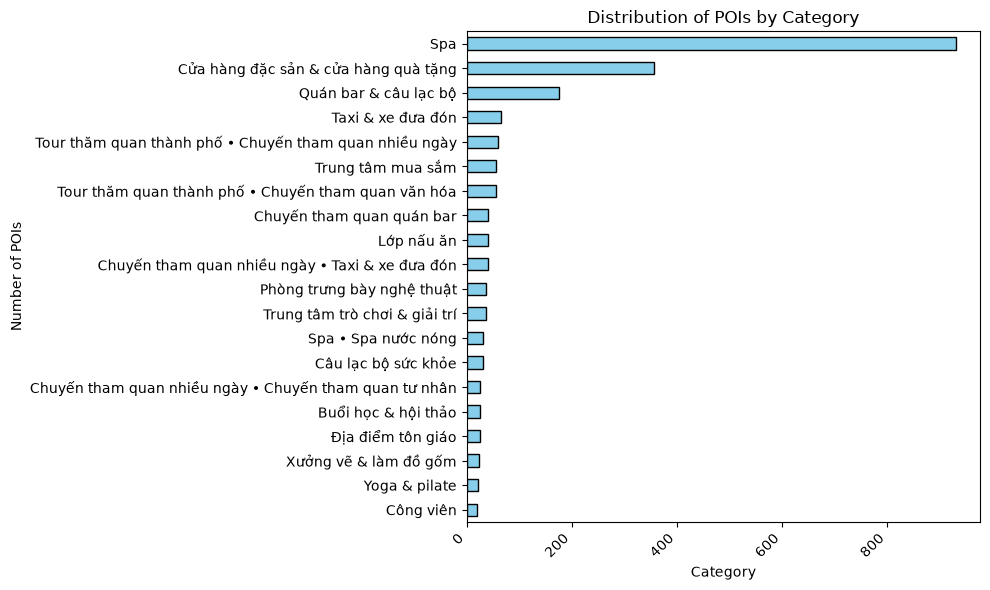

In [18]:
# Phân bố các POI theo Danh mục

# Gộp df_poi_belongsto_category với df_node_category để lấy tên danh mục
poi_category_names = df_poi_belongsto_category.merge(df_node_category, left_on='category_id', right_on='id', how='left')

# Tính số lượng POI theo tên danh mục
attraction_counts = poi_category_names['name'].value_counts()

# Top 20 danh mục
top_20_categories = attraction_counts.head(20)

# Vẽ biểu đồ phân bố các POI theo tên danh mục
plt.figure(figsize=(10, 6))
top_20_categories.sort_values(ascending=True).plot(kind='barh', color='skyblue', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Number of POIs')
plt.title('Distribution of POIs by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


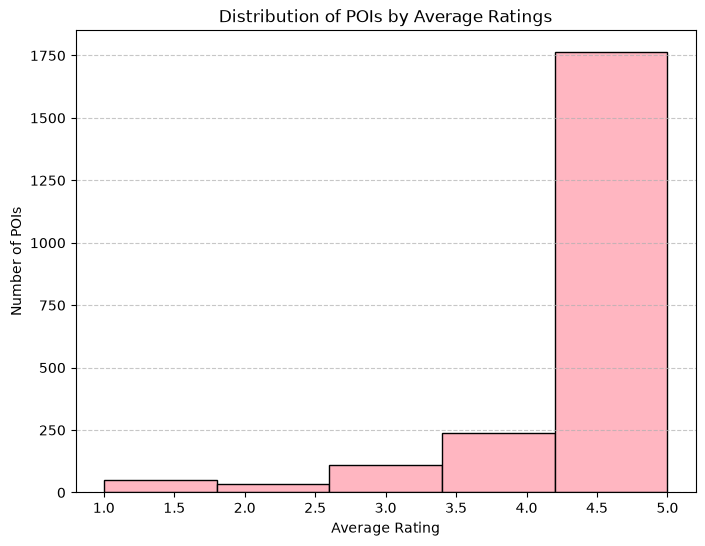

In [19]:
# Phân bố các POI theo Điểm đánh giá trung bình

plt.figure(figsize=(8, 6))
df_poi_info['avgRating'].plot(kind='hist', bins=5, color='lightpink', edgecolor='black')
plt.xlabel('Average Rating')
plt.ylabel('Number of POIs')
plt.title('Distribution of POIs by Average Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


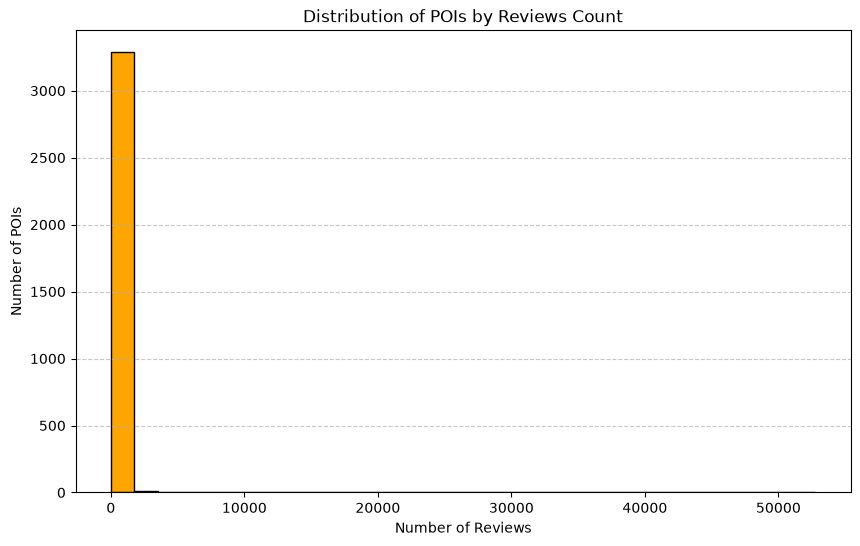

In [20]:
# Phân bố các POI theo Số lượng đánh giá

plt.figure(figsize=(10, 6))
df_poi_info['numReviews'].plot(kind='hist', bins=30, color='orange', edgecolor='black')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of POIs')
plt.title('Distribution of POIs by Reviews Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

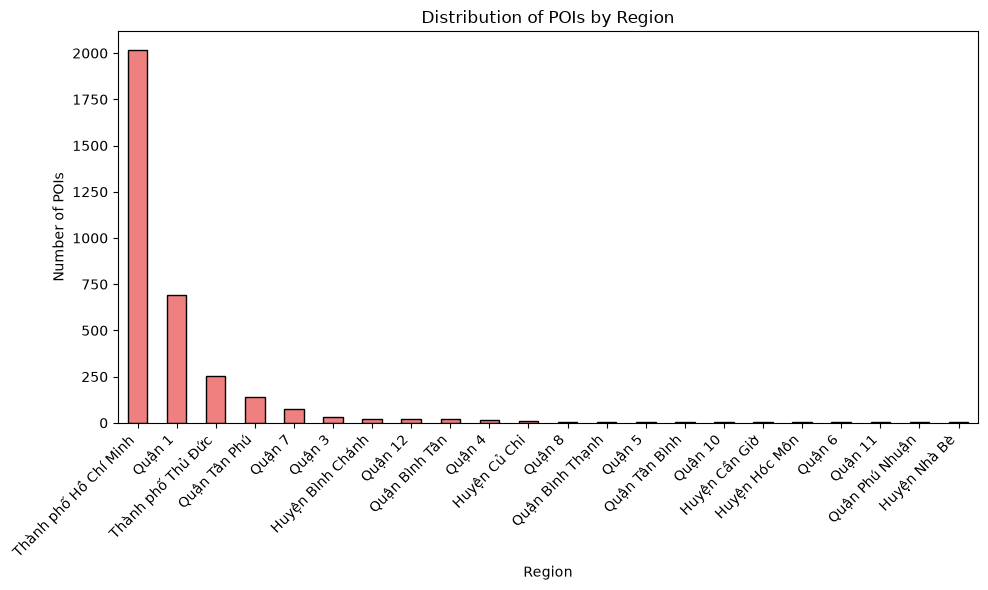

In [21]:
# Phân bố các POI theo Vùng (Region)

region_counts = df_poi_info['region'].value_counts()
plt.figure(figsize=(10, 6))
region_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.xlabel('Region')
plt.ylabel('Number of POIs')
plt.title('Distribution of POIs by Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

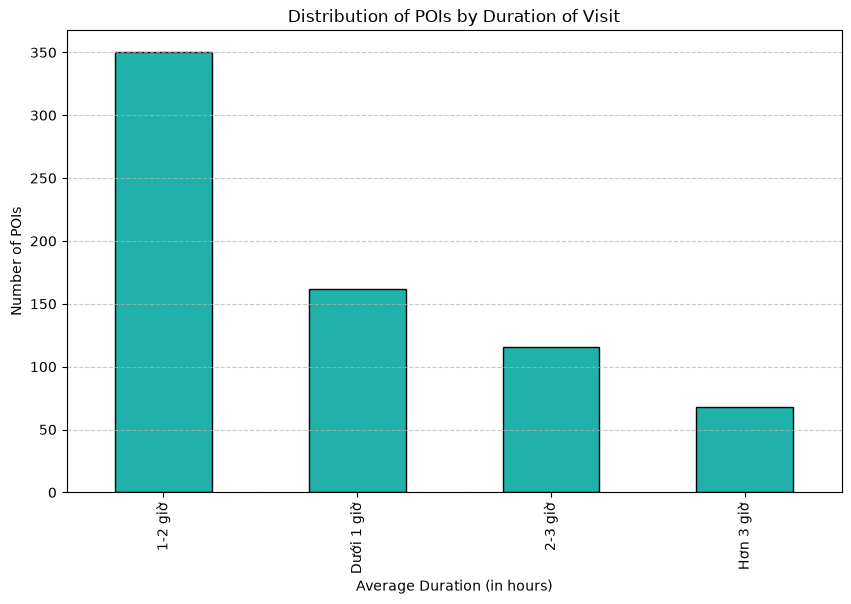

In [22]:
# Phân bố các POI theo Thời lượng tham quan

if not df_node_poi['duration'].dropna().empty:
    duration_counts = df_node_poi['duration'].value_counts()
    plt.figure(figsize=(10, 6))
    duration_counts.plot(kind='bar', color='lightseagreen', edgecolor='black')

    plt.xlabel('Average Duration (in hours)')
    plt.ylabel('Number of POIs')
    plt.title('Distribution of POIs by Duration of Visit')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Không có dữ liệu duration để hiển thị biểu đồ.")


In [23]:
# Phân bố các POI theo Khoảng giá
if not df_node_poi['price'].dropna().empty:
    plt.figure(figsize=(8, 6))
    df_node_poi['price'].plot(kind='hist', bins=40, color='gold', edgecolor='black')
    plt.xlabel('Price Range')
    plt.ylabel('Number of POIs')
    plt.title('Distribution of POIs by Price Range')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Không có dữ liệu price để hiển thị biểu đồ.")


Không có dữ liệu price để hiển thị biểu đồ.


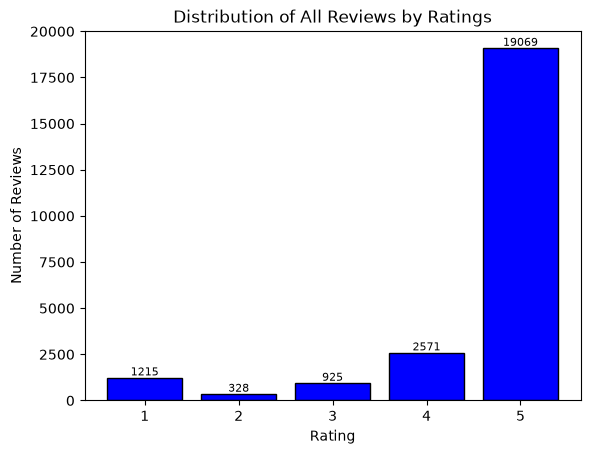

In [24]:
# Phân bố của tất cả đánh giá theo Điểm số

# Đếm số lần xuất hiện của mỗi điểm số
rating_counts = df_reviews['rating'].value_counts().sort_index()

# Vẽ biểu đồ phân bố điểm số
plt.bar(rating_counts.index, rating_counts.values, color='blue', edgecolor='black')

# Thiết lập các vạch trên trục hoành chỉ hiển thị 1, 2, 3, 4, 5
plt.xticks(range(1, 6))

# Thêm nhãn và tiêu đề
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of All Reviews by Ratings')

# Thêm nhãn văn bản trên đầu mỗi cột
for i, count in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], count, str(count), ha='center', va='bottom', fontsize=8)

# Hiển thị biểu đồ
plt.show()

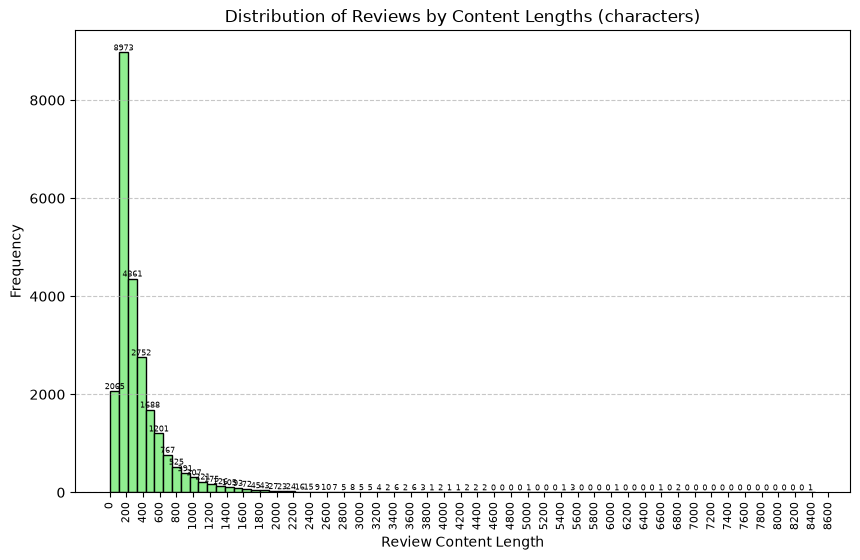

In [25]:
# Phân bố đánh giá theo Độ dài nội dung (ký tự)

# Tính độ dài của mỗi đánh giá
df_reviews['review_length'] = df_reviews['content'].apply(lambda x: len(str(x)))
# Vẽ biểu đồ phân bố độ dài đánh giá
plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(df_reviews['review_length'], bins=80, color='lightgreen', edgecolor='black')
max_length = int(df_reviews['content'].str.len().max())
plt.xticks(np.arange(0, max_length + 200, 200), rotation=90, fontsize=8)
plt.xlabel('Review Content Length')
plt.ylabel('Frequency')
plt.title('Distribution of Reviews by Content Lengths (characters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số lượng trên đầu mỗi cột
for count, bin_edge in zip(counts, bins):
    plt.text(bin_edge + (bins[1] - bins[0]) / 2, count, str(int(count)), ha='center', va='bottom', fontsize=6)

plt.show()

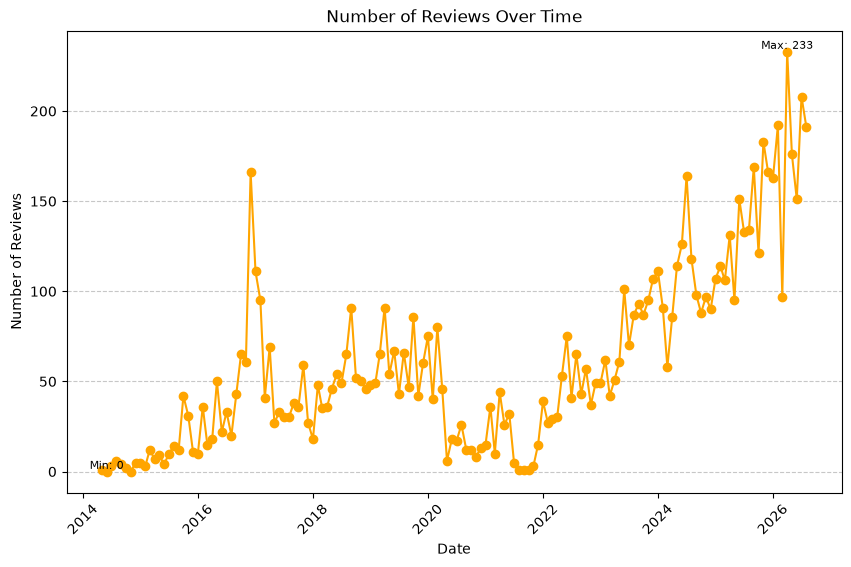

In [26]:
# Phân tích đánh giá theo thời gian

# Convert 'date' column to datetime format
df_reviews['date'] = pd.to_datetime(df_reviews['date'], format='%d tháng %m, %Y', errors='coerce')

# Vẽ biểu đồ số lượng đánh giá theo thời gian
plt.figure(figsize=(10, 6))
reviews_over_time = df_reviews.groupby(pd.Grouper(key='date', freq='ME')).size().reset_index(name='num_reviews')
plt.plot(reviews_over_time['date'], reviews_over_time['num_reviews'], marker='o', color='orange')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.title('Number of Reviews Over Time')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm các điểm cực đại và cực tiểu
max_point = reviews_over_time.loc[reviews_over_time['num_reviews'].idxmax()]
min_point = reviews_over_time.loc[reviews_over_time['num_reviews'].idxmin()]
plt.text(max_point['date'], max_point['num_reviews'], f"Max: {max_point['num_reviews']}", ha='center', va='bottom', fontsize=8)
plt.text(min_point['date'], min_point['num_reviews'], f"Min: {min_point['num_reviews']}", ha='center', va='bottom', fontsize=8)

plt.show()


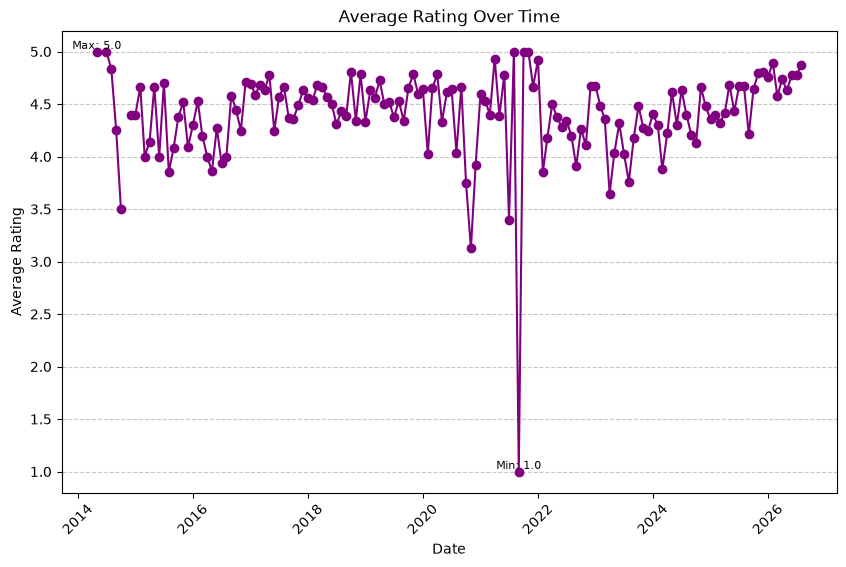

In [ ]:
# Xu hướng điểm đánh giá trung bình theo thời gian

# Convert 'date' column to datetime format
df_reviews['date'] = pd.to_datetime(df_reviews['date'], format='%d tháng %m, %Y', errors='coerce')

# Tính điểm đánh giá trung bình theo tháng
average_rating_over_time = df_reviews.groupby(pd.Grouper(key='date', freq='ME'))['rating'].mean().reset_index()

# Vẽ biểu đồ điểm đánh giá trung bình theo thời gian
plt.figure(figsize=(10, 6))
plt.plot(average_rating_over_time['date'], average_rating_over_time['rating'], marker='o', color='purple')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Time')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm các điểm cực đại và cực tiểu
max_point = average_rating_over_time.loc[average_rating_over_time['rating'].idxmax()]
min_point = average_rating_over_time.loc[average_rating_over_time['rating'].idxmin()]
plt.text(max_point['date'], max_point['rating'], f"Max: {max_point['rating']}", ha='center', va='bottom', fontsize=8)
plt.text(min_point['date'], min_point['rating'], f"Min: {min_point['rating']}", ha='center', va='bottom', fontsize=8)

plt.show()

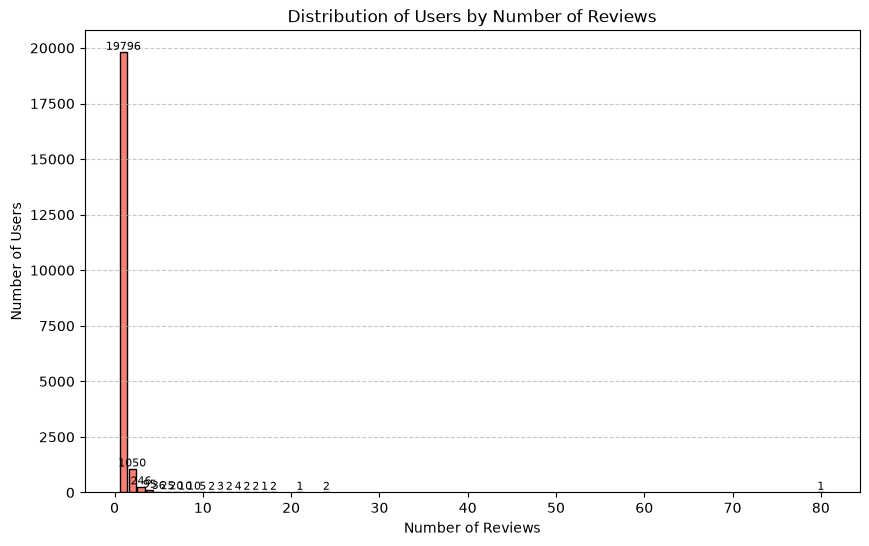

In [ ]:
# Phân bố người dùng theo Số lượng đánh giá

# Nhóm các đánh giá theo người dùng và đếm số lượng đánh giá của mỗi người
user_review_counts = df_reviews.groupby('username').size().reset_index(name='review_count')

# Tính tần suất người dùng theo số lượng đánh giá
user_review_frequency = user_review_counts['review_count'].value_counts().reset_index()
user_review_frequency.columns = ['Number of Reviews', 'Frequency']

# Sắp xếp dataframe theo số lượng đánh giá
user_review_frequency = user_review_frequency.sort_values(by='Number of Reviews')

# Vẽ biểu đồ phân bố người dùng theo số lượng đánh giá
plt.figure(figsize=(10, 6))
bars = plt.bar(user_review_frequency['Number of Reviews'], user_review_frequency['Frequency'], color='salmon', edgecolor='black')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users')
plt.title('Distribution of Users by Number of Reviews')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm chú thích cho từng cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=8)

plt.show()

In [43]:
'''
#some color options to differentiate between graphs:

lightblue
salmon
lightgreen
gold
lightcoral
lightskyblue
lightseagreen
lightpink
lightsteelblue
lightgray
'''

'\n#some color options to differentiate between graphs:\n\nlightblue\nsalmon\nlightgreen\ngold\nlightcoral\nlightskyblue\nlightseagreen\nlightpink\nlightsteelblue\nlightgray\n'

# Xuất dữ liệu đã xử lý ra các file .csv

In [15]:
# Thư mục để lưu các file CSV
directory = 'neo4j_import'

# Hàm làm sạch dấu gạch chéo ngược ở cuối chuỗi tránh lỗi Neo4j LOAD CSV
def clean_trailing_backslashes(df):
    import pandas as pd
    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].fillna('').astype(str).apply(lambda x: x[:-1] if x.endswith('\\') else x)
    return df

df_node_poi = clean_trailing_backslashes(df_node_poi)
df_node_category = clean_trailing_backslashes(df_node_category)
df_node_region = clean_trailing_backslashes(df_node_region)
df_node_user = clean_trailing_backslashes(df_node_user)
df_node_origin = clean_trailing_backslashes(df_node_origin)
df_node_review = clean_trailing_backslashes(df_node_review)
df_node_ward = clean_trailing_backslashes(df_node_ward)
df_node_district = clean_trailing_backslashes(df_node_district)

# Tạo thư mục nếu nó chưa tồn tại
if not os.path.exists(directory):
    os.makedirs(directory)

# Lưu df_node_poi
df_node_poi.to_csv(os.path.join(directory, 'df_node_poi.csv'), index=False)

# Lưu df_node_category
df_node_category.to_csv(os.path.join(directory, 'df_node_category.csv'), index=False)

# Lưu df_node_region
df_node_region.to_csv(os.path.join(directory, 'df_node_region.csv'), index=False)

# Lưu df_node_user
df_node_user.to_csv(os.path.join(directory, 'df_node_user.csv'), index=False)

# Lưu df_node_origin
df_node_origin.to_csv(os.path.join(directory, 'df_node_origin.csv'), index=False)


# Lưu df_node_review
# df_node_review.to_csv(os.path.join(directory, 'df_node_review.csv'), index=False)

# Chia DataFrame thành hai nửa
half_len = len(df_node_review) // 2
df_node_review_1 = df_node_review.iloc[:half_len]
df_node_review_2 = df_node_review.iloc[half_len:]

# Lưu mỗi nửa vào các file CSV riêng biệt
df_node_review_1.to_csv(os.path.join(directory, 'df_node_review_1.csv'), index=False)
df_node_review_2.to_csv(os.path.join(directory, 'df_node_review_2.csv'), index=False)


# Lưu df_poi_belongsto_category
df_poi_belongsto_category.to_csv(os.path.join(directory, 'df_poi_belongsto_category.csv'), index=False)

# Lưu df_poi_locatedat_region
df_poi_locatedat_region.to_csv(os.path.join(directory, 'df_poi_locatedat_region.csv'), index=False)

# Lưu df_user_reviewed_poi
df_user_reviewed_poi.to_csv(os.path.join(directory, 'df_user_reviewed_poi.csv'), index=False)

# Lưu df_user_from_origin
df_user_from_origin.to_csv(os.path.join(directory, 'df_user_from_origin.csv'), index=False)

# Lưu df_node_ward
df_node_ward.to_csv(os.path.join(directory, 'df_node_ward.csv'), index=False)

# Lưu df_node_district
df_node_district.to_csv(os.path.join(directory, 'df_node_district.csv'), index=False)

# Lưu df_poi_locatedin_ward
df_poi_locatedin_ward.to_csv(os.path.join(directory, 'df_poi_locatedin_ward.csv'), index=False)

# Lưu df_ward_mergedto_ward
df_ward_mergedto_ward.to_csv(os.path.join(directory, 'df_ward_mergedto_ward.csv'), index=False)